TODO : curate null (empty) customer IDs
keep the results with those IDs and compare without IDs

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
pd.plotting.register_matplotlib_converters()

%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


<Axes: xlabel='Quantity', ylabel='UnitPrice'>

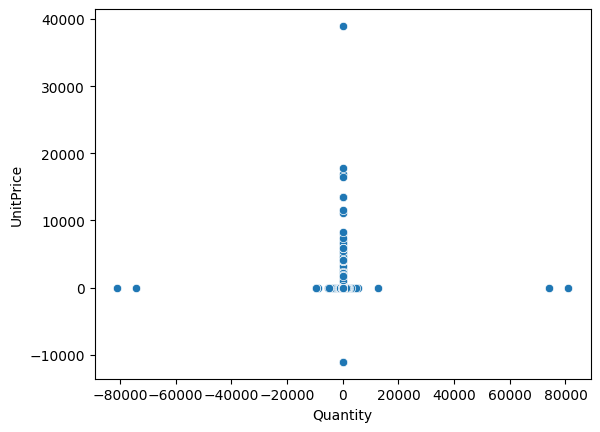

In [9]:
df = pd.read_excel('data.xlsx') # reads the excel file
df_original = pd.read_excel('data.xlsx') #copy it for further comparisons
sns.scatterplot(x="Quantity",y="UnitPrice",data=df) # creates a scatter plot with columns xvar and yvar

In [10]:
df.info()
#Here we can see 8 different columns are contained in this file
#Not all of them are useful for our application
#InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country
df.nunique()

#We can see there are 25 900 different invoices
#4 070 different stock codes (products)
#

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

Original number of rows :  541909
Number of rows in DF after removing duplicates : 397924
Number of rows in DF after removing negative prices : 397924
Number of rows in DF after removing negative quantities : 397924
Number of rows in DF after removing empty description : 397924
A closer look at the data reveals a link between missing decription and missing customer ID


<Axes: xlabel='Quantity', ylabel='UnitPrice'>

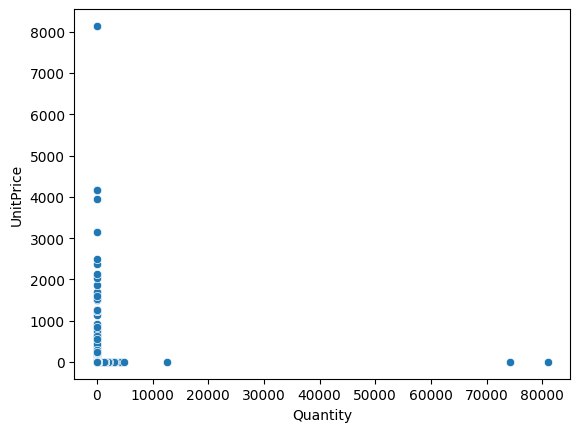

In [14]:
#remove duplicates

print("Original number of rows : ", len(df_original.index))
df.drop_duplicates()
print("Number of rows in DF after removing duplicates :", len(df.index))
#no duplicate rows apparent

#remove rows where unit price < 0

df = df[df['UnitPrice'] >= 0]
print("Number of rows in DF after removing negative prices :", len(df.index))

#remove rows where quantity < 0

df = df[df['Quantity'] >= 0]
print("Number of rows in DF after removing negative quantities :", len(df.index))

df = df[df['CustomerID'].notnull()]

df_no_null_customer = df[df['Description'].notnull()]
print("Number of rows in DF after removing empty description :", len(df_no_null_customer.index))

print("A closer look at the data reveals a link between missing decription and missing customer ID")

sns.scatterplot(x="Quantity",y="UnitPrice",data=df)

In [15]:
#how about we remove the extremes ?



In [16]:
df.head()
#about the data :
#stockcode and description are redundant
#invoiceDate is not exploitable
#customerID is not exploitable
#country is not exploitable
#Reminder : we are looking for some association rules between products
#unitPrice is not exploitable (unsure) (maybe interesting to see price evolve with quantity)

to_drop = ['InvoiceDate',
           'Country',
           'CustomerID',
           'StockCode']

to_drop_original = ['InvoiceDate',
           'Country',
           'CustomerID',
           'stockCode']

In [17]:
#drop those tables

df_original.drop(to_drop, inplace=True, axis=1)

df_original.head()

,InvoiceNo,Description,Quantity,UnitPrice
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55
1,536365,WHITE METAL LANTERN,6,3.39
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39


In [18]:
df_original.head()

,InvoiceNo,Description,Quantity,UnitPrice
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55
1,536365,WHITE METAL LANTERN,6,3.39
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39


In [19]:
#for association rules I will need to convert each product into a boolean
#and group orders by Description
df_original = df_original.pivot_table(
              index='InvoiceNo', 
              columns='Description', 
              values='Quantity', 
              aggfunc='sum').fillna(0).astype(bool)

df_original.head()

Description,20713,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,...,wrongly coded 20713,wrongly coded 23343,wrongly coded-23343,wrongly marked,wrongly marked 23343,wrongly marked carton 22804,wrongly marked. 23343 in box,wrongly sold (22719) barcode,wrongly sold as sets,wrongly sold sets
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536366,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536367,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536369,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [20]:
# Support value for single items
support = df_original.mean().sort_values(ascending=False)
support.head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    0.094167
REGENCY CAKESTAND 3 TIER              0.088726
JUMBO BAG RED RETROSPOT               0.087335
PARTY BUNTING                         0.069786
LUNCH BAG RED RETROSPOT               0.065737
ASSORTED COLOUR BIRD ORNAMENT         0.060010
SET OF 3 CAKE TINS PANTRY DESIGN      0.059642
PACK OF 72 RETROSPOT CAKE CASES       0.054569
LUNCH BAG  BLACK SKULL.               0.052974
NATURAL SLATE HEART CHALKBOARD        0.051788
dtype: float64

In [21]:
from mlxtend.frequent_patterns import association_rules, apriori

# Apply Apriori algorithm
frequent_itemsets = apriori(df_original, min_support=0.01, use_colnames=True)

In [22]:
frequent_itemsets.sort_values(by='support', ascending=False).head(20)

,support,itemsets
609,0.094167,(WHITE HANGING HEART T-LIGHT HOLDER)
434,0.088726,(REGENCY CAKESTAND 3 TIER)
258,0.087335,(JUMBO BAG RED RETROSPOT)
353,0.069786,(PARTY BUNTING)
294,0.065737,(LUNCH BAG RED RETROSPOT)
38,0.060010,(ASSORTED COLOUR BIRD ORNAMENT)
490,0.059642,(SET OF 3 CAKE TINS PANTRY DESIGN )
336,0.054569,(PACK OF 72 RETROSPOT CAKE CASES)
286,0.052974,(LUNCH BAG BLACK SKULL.)
316,0.051788,(NATURAL SLATE HEART CHALKBOARD )


In [23]:
# Compute association rules

rules = association_rules(frequent_itemsets, metric="confidence", 
  min_threshold=0.5)

In [24]:
#We obtain the table with
#support
#between 0 and 1 and represents the percentage of times where this transaction happens
#ex : 1,8% of transactions have 60 TEATIME FAIRY CAKE CASES and PACK OF 72 RETROSPOT CAKE CASES

#confidence
#between 0 and 1 and represents the percentage of times where a transaction with A will have B as well
#ex : 54,8% of transactions containing 60 TEATIME FAIRY CAKE CASES will also have PACK OF 72 RETROSPOT CAKE CASES

#lift
#lift is used to make the difference between a product that occurs frequently in general and a product that occurs frequently
#in a specific association
#We want to avoid considering meaningless associations (example of the paper bag being bought always with the apple)
#ex : 60 TEATIME FAIRY CAKE CASES and PACK OF 72 RETROSPOT CAKE CASES have a lift of 10, which is excellent,
#it means those two products are not only often bought together, but also not always bought all the time with anything else

#leverage


#conviction
#serves to measure how much a consequent depends on antecedant
#a high conviction means the consequent is highly dependant on the antecedant

#zhangs_metric
rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(60 TEATIME FAIRY CAKE CASES),(PACK OF 72 RETROSPOT CAKE CASES),0.034198,0.054569,0.018735,0.547847,10.039479,1.0,0.016869,2.090953,0.932275,0.267523,0.521749,0.445588
1,(ALARM CLOCK BAKELIKE CHOCOLATE),(ALARM CLOCK BAKELIKE GREEN),0.018040,0.040947,0.011372,0.630385,15.395009,1.0,0.010633,2.594737,0.952222,0.238832,0.614605,0.454054
2,(ALARM CLOCK BAKELIKE CHOCOLATE),(ALARM CLOCK BAKELIKE RED ),0.018040,0.044220,0.012108,0.671202,15.178723,1.0,0.011311,2.906890,0.951279,0.241436,0.655990,0.472511
3,(ALARM CLOCK BAKELIKE IVORY),(ALARM CLOCK BAKELIKE GREEN),0.023848,0.040947,0.013745,0.576329,14.074872,1.0,0.012768,2.263675,0.951647,0.269231,0.558240,0.455997
4,(ALARM CLOCK BAKELIKE ORANGE),(ALARM CLOCK BAKELIKE GREEN),0.018899,0.040947,0.011331,0.599567,14.642375,1.0,0.010557,2.395039,0.949652,0.233558,0.582470,0.438145
5,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.032684,0.040947,0.017140,0.524406,12.806810,1.0,0.015801,2.016534,0.953067,0.303403,0.504100,0.471493
6,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.040947,0.044220,0.026426,0.645355,14.594209,1.0,0.024615,2.695031,0.971250,0.449861,0.628947,0.621475
7,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.044220,0.040947,0.026426,0.597595,14.594209,1.0,0.024615,2.383301,0.974575,0.449861,0.580414,0.621475
8,(ALARM CLOCK BAKELIKE IVORY),(ALARM CLOCK BAKELIKE RED ),0.023848,0.044220,0.015422,0.646655,14.623621,1.0,0.014367,2.704950,0.954378,0.292929,0.630307,0.497703
9,(ALARM CLOCK BAKELIKE ORANGE),(ALARM CLOCK BAKELIKE RED ),0.018899,0.044220,0.012681,0.670996,15.174061,1.0,0.011845,2.905068,0.952091,0.251419,0.655774,0.478884


In [25]:
# That's it for now !
# Everything after is past attempts / dead ends

In [26]:
#Let's group by InvoiceNo
#https://www.skytowner.com/explore/merging_rows_within_a_group_together_in_pandas
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df['StockCode'] = df['StockCode'].astype(str)
#convert invoice number to str for further work
new_df = df.groupby('InvoiceNo', as_index=False).agg({'InvoiceNo' : 'first', 'StockCode' : ' '.join})
new_df.head()
#problem : I lost other columns
#This dataframe can be helpful to find which product goes with which product, regardless of quantity and unit price

,InvoiceNo,StockCode
0,536365,85123A 71053 84406B 84029G 84029E 22752 21730
1,536366,22633 22632
2,536367,84879 22745 22748 22749 22310 84969 22623 2262...
3,536368,22960 22913 22912 22914
4,536369,21756


In [27]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [28]:
#remove negative data
#having negative quantities and negative prices is incoherent, so we need to remove them



In [29]:
#drop the StockCode or Description as they represent the same information (each product as a defined stockCode)



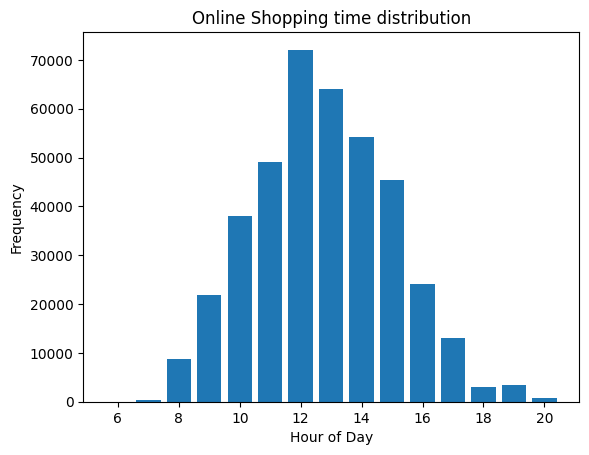

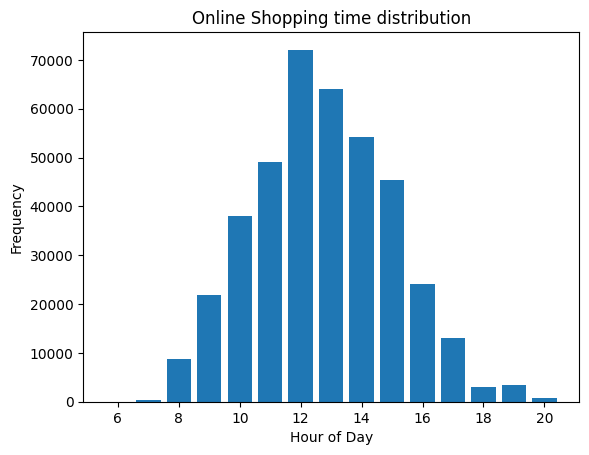

In [30]:
##################### new
# Online shopping time distribution
# Convert the transactionDate column to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract the hour information from the transactionDate column
df['hour'] = df['InvoiceDate'].dt.hour

# Count the frequency of purchases by hour
hour_counts = df['hour'].value_counts().sort_index()

# Create a bar chart of the frequency of purchases by hour
plt.bar(hour_counts.index, hour_counts.values)
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.title('Online Shopping time distribution')
plt.show()

# we can see from the plot that thers is a bias between the hour of day and order volume.
# Most orders happens between 10:00 and 16:00

#no null customer df_no_null_customer
df_no_null_customer['InvoiceDate'] = pd.to_datetime(df_no_null_customer['InvoiceDate'])

# Extract the hour information from the transactionDate column
df_no_null_customer['hour'] = df_no_null_customer['InvoiceDate'].dt.hour

# Count the frequency of purchases by hour
hour_counts = df_no_null_customer['hour'].value_counts().sort_index()

# Create a bar chart of the frequency of purchases by hour
plt.bar(hour_counts.index, hour_counts.values)
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.title('Online Shopping time distribution')
plt.show()


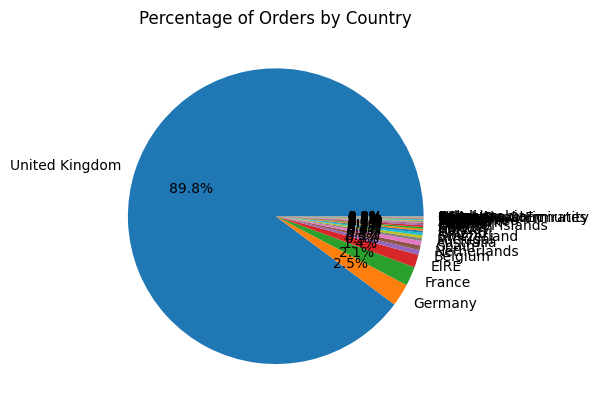

Text(0.5, 1.0, 'Quantity ratio by countries')

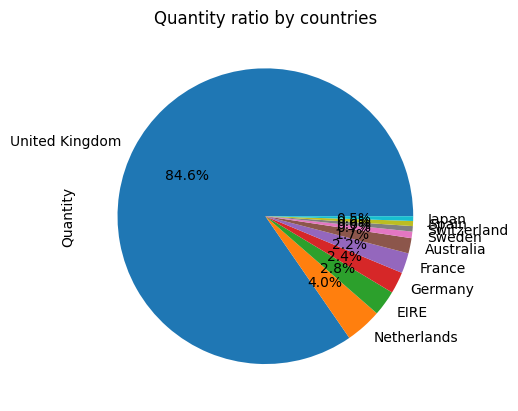

In [31]:
""""
# code for percentage of orders by country with a set size for the pie chart
# Orders by country and finding the top country
# Group the data by country
country_counts = df.groupby('Country').agg({'InvoiceNo': 'nunique'}).reset_index()

# Calculate the percentage of orders for each country
country_counts['pct'] = country_counts['InvoiceNo'] / country_counts['InvoiceNo'].sum()

# Sort the data by percentage
country_counts = country_counts.sort_values('pct', ascending=False)

# Create a pie chart of the percentage of orders for each country
plt.figure(figsize=(15, 8))
plt.pie(country_counts['pct'], labels=country_counts['Country'], autopct='%1.1f%%')
plt.title('Percentage of Orders by Country')
plt.show()
"""
# Orders by country and finding the top country
# Group the data by country
country_counts = df.groupby('Country').agg({'InvoiceNo': 'nunique'}).reset_index()

# Calculate the percentage of orders for each country
country_counts['pct'] = country_counts['InvoiceNo'] / country_counts['InvoiceNo'].sum()

# Sort the data by percentage
country_counts = country_counts.sort_values('pct', ascending=False)

# Create a pie chart of the percentage of orders for each country
plt.pie(country_counts['pct'], labels=country_counts['Country'], autopct='%1.1f%%')

plt.title('Percentage of Orders by Country')
plt.show()
#plot.pie(autopct="%1.1f%%",figsize=(15, 8))

# we can se that most transactions come from from the UK

# Quantity ratio by country 
df.groupby('Country')['Quantity'].sum().sort_values(ascending=False).head(10).plot.pie(autopct="%1.1f%%");
plt.title('Quantity ratio by countries')
#df.groupby('Country')['Quantity'].sum().sort_values(ascending=False).head(10).plot.pie(autopct="%1.1f%%",figsize=(15, 8));


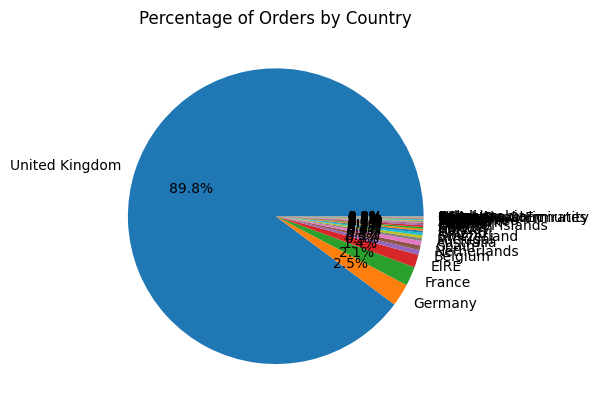

Text(0.5, 1.0, 'Quantity ratio by countries')

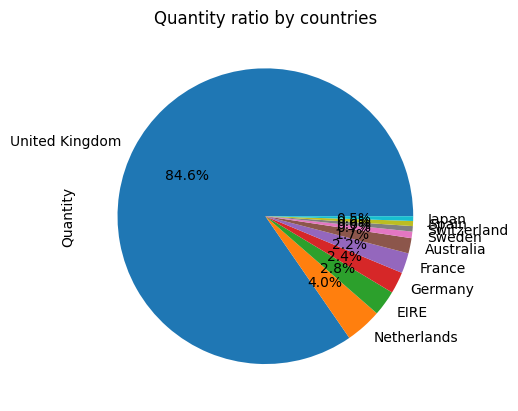

In [32]:
# no null customer
# Orders by country and finding the top country
# Group the data by country
country_counts = df_no_null_customer.groupby('Country').agg({'InvoiceNo': 'nunique'}).reset_index()

# Calculate the percentage of orders for each country
country_counts['pct'] = country_counts['InvoiceNo'] / country_counts['InvoiceNo'].sum()

# Sort the data by percentage
country_counts = country_counts.sort_values('pct', ascending=False)

# Create a pie chart of the percentage of orders for each country
plt.pie(country_counts['pct'], labels=country_counts['Country'], autopct='%1.1f%%')
plt.title('Percentage of Orders by Country')
plt.show()
#plot.pie(autopct="%1.1f%%",figsize=(15, 8))

# we can se that most transactions come from from the UK

# Quantity ratio by country 
df.groupby('Country')['Quantity'].sum().sort_values(ascending=False).head(10).plot.pie(autopct="%1.1f%%");
plt.title('Quantity ratio by countries')


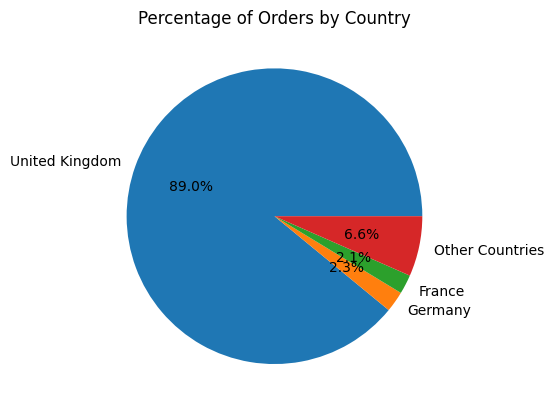

In [33]:
# Orders by country and finding the top countries
# Filter the data for the specified countries
specified_countries = ['United Kingdom', 'France', 'Germany']
filtered_df = df_no_null_customer[df_no_null_customer['Country'].isin(specified_countries)]

# Group the data by country
country_counts = filtered_df['Country'].value_counts()

# Calculate the percentage of orders for each country
country_pct = country_counts / country_counts.sum()

# Get the countries other than the specified countries
other_countries = df_no_null_customer[~df_no_null_customer['Country'].isin(specified_countries)]['Country']

# Count the orders for each other country
other_country_counts = other_countries.value_counts()

# Calculate the percentage for "Other Country" (sum of percentages of all other countries)
other_country_pct = other_country_counts.sum() / country_counts.sum()

# Create a new DataFrame with the specified countries and the "Other Country" slice
top_countries = pd.concat([country_pct, pd.Series({'Other Countries': other_country_pct})])

# Create a pie chart of the percentage of orders for each country
plt.pie(top_countries, labels=top_countries.index, autopct='%1.1f%%')

plt.title('Percentage of Orders by Country')
plt.show()



#df.groupby('Country')['Quantity'].sum().sort_values(ascending=False).head(10).plot.pie(autopct="%1.1f%%");
#plt.title('Quantity ratio by countries')


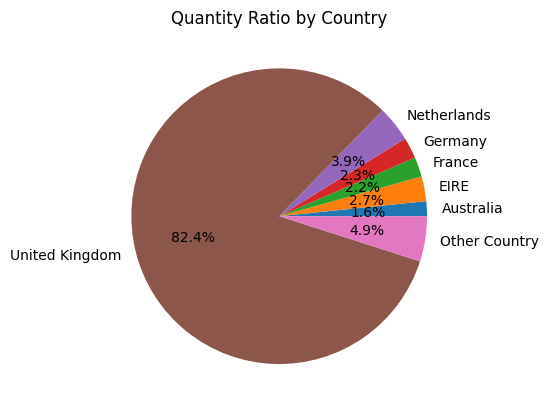

In [34]:
specified_countries = ['United Kingdom', 'Netherlands', 'EIRE','Germany','France','Australia']
filtered_df = df_no_null_customer[df_no_null_customer['Country'].isin(specified_countries)]

# Group the data by country
country_quantity = filtered_df.groupby('Country')['Quantity'].sum()

other_countries = df_no_null_customer[~df_no_null_customer['Country'].isin(specified_countries)]['Country']

other_country_quantity = df_no_null_customer[df_no_null_customer['Country'].isin(other_countries)]['Quantity'].sum()



top_countries = pd.concat([country_quantity, pd.Series({'Other Country': other_country_quantity})])

plt.pie(top_countries, labels=top_countries.index, autopct='%1.1f%%')

plt.title('Quantity Ratio by Country')
plt.show()

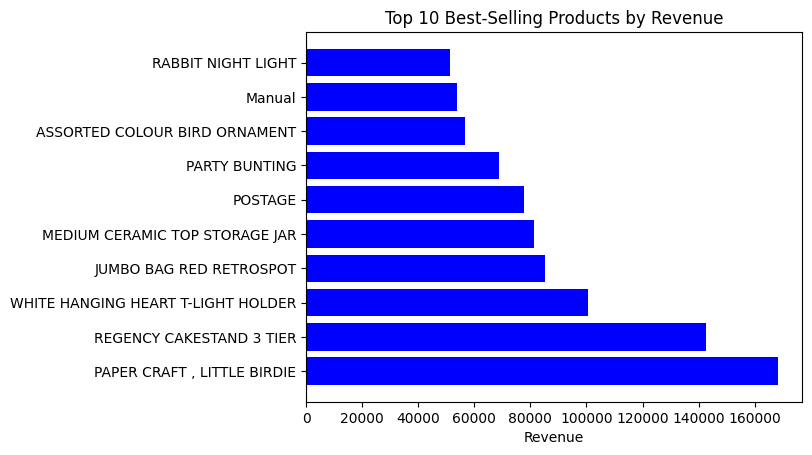

In [35]:


# Convert the data types of the columns
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df['StockCode'] = df['StockCode'].astype(str)
df['Description'] = df['Description'].astype(str)
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')
df['CustomerID'] = df['CustomerID'].astype(str)
df['Country'] = df['Country'].astype(str)

# Calculate the total revenue for each product
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Calculate the top 10 best-selling products by revenue
top_products = df.groupby(['Description'])['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)[:10]

# Calculate the mean revenue across all products
mean_revenue = df['Revenue'].mean()

# Create a new column to indicate whether the revenue is above or below the mean
top_products['Above_Mean'] = top_products['Revenue'] > mean_revenue

# Set the color for the bars based on whether the revenue is above or below the mean
colors = top_products['Above_Mean'].map({True: 'blue', False: 'red'})

# Create the diverging bar chart
plt.barh(top_products['Description'], top_products['Revenue'], color=colors)
plt.axvline(x=mean_revenue, color='black', linestyle='--')
plt.xlabel('Revenue')
plt.title('Top 10 Best-Selling Products by Revenue')
plt.show()


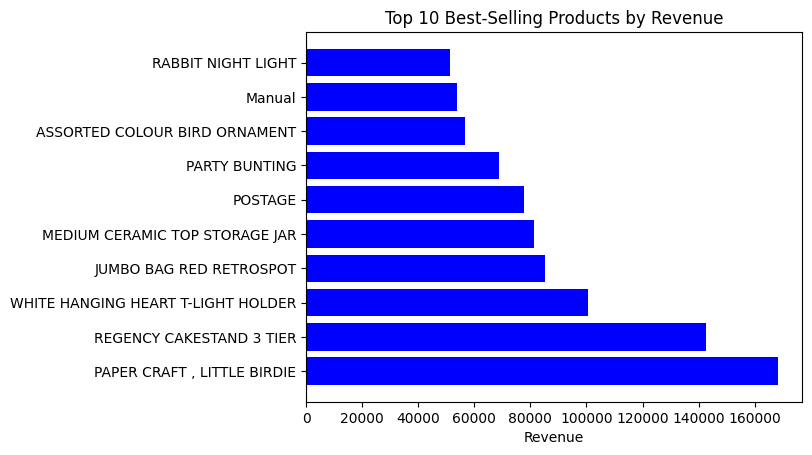

In [36]:
# Convert the data types of the columns
df_no_null_customer['InvoiceNo'] = df_no_null_customer['InvoiceNo'].astype(str)
df_no_null_customer['StockCode'] = df_no_null_customer['StockCode'].astype(str)
df_no_null_customer['Description'] = df_no_null_customer['Description'].astype(str)
df_no_null_customer['Quantity'] = pd.to_numeric(df_no_null_customer['Quantity'], errors='coerce')
df_no_null_customer['InvoiceDate'] = pd.to_datetime(df_no_null_customer['InvoiceDate'])
df_no_null_customer['UnitPrice'] = pd.to_numeric(df_no_null_customer['UnitPrice'], errors='coerce')
df_no_null_customer['CustomerID'] = df_no_null_customer['CustomerID'].astype(str)
df_no_null_customer['Country'] = df_no_null_customer['Country'].astype(str)

# Calculate the total revenue for each product
df_no_null_customer['Revenue'] = df_no_null_customer['Quantity'] * df_no_null_customer['UnitPrice']

# Calculate the top 10 best-selling products by revenue
top_products = df_no_null_customer.groupby(['Description'])['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)[:10]

# Calculate the mean revenue across all products
mean_revenue = df_no_null_customer['Revenue'].mean()

# Create a new column to indicate whether the revenue is above or below the mean
top_products['Above_Mean'] = top_products['Revenue'] > mean_revenue

# Set the color for the bars based on whether the revenue is above or below the mean
colors = top_products['Above_Mean'].map({True: 'blue', False: 'red'})

# Create the diverging bar chart
plt.barh(top_products['Description'], top_products['Revenue'], color=colors)
plt.axvline(x=mean_revenue, color='black', linestyle='--')
plt.xlabel('Revenue')
plt.title('Top 10 Best-Selling Products by Revenue')
plt.show()


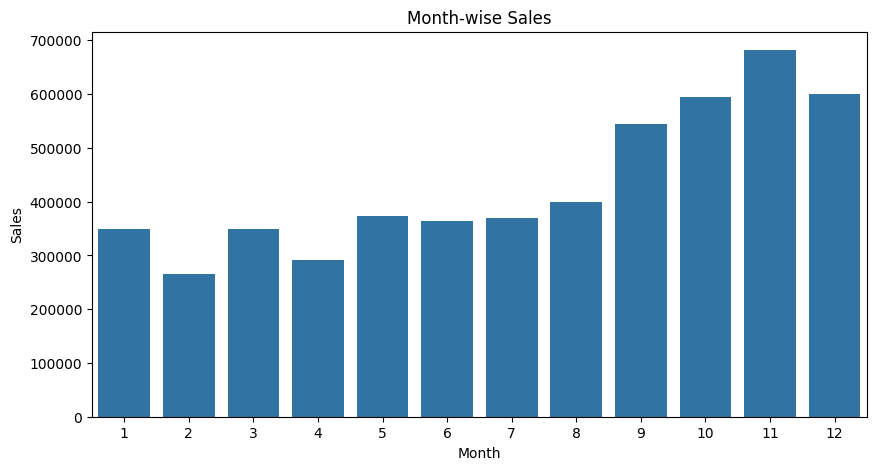

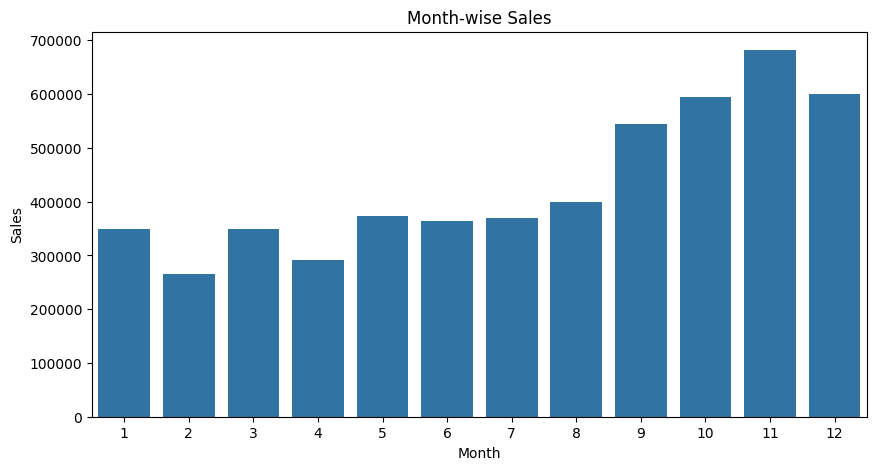

In [37]:

import seaborn as sns


# Convert the 'InvoiceDate' column to datetime type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Group the data by month and calculate the total sales
sales_by_month = df.groupby(df['InvoiceDate'].dt.month)['Quantity'].sum()

# Create the bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_month.index, y=sales_by_month.values)
plt.title("Month-wise Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

# Show the plot
plt.show()


# no null customer

# Convert the 'InvoiceDate' column to datetime type
df_no_null_customer['InvoiceDate'] = pd.to_datetime(df_no_null_customer['InvoiceDate'])

# Group the data by month and calculate the total sales
sales_by_month = df_no_null_customer.groupby(df_no_null_customer['InvoiceDate'].dt.month)['Quantity'].sum()

# Create the bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_month.index, y=sales_by_month.values)
plt.title("Month-wise Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

# Show the plot
plt.show()


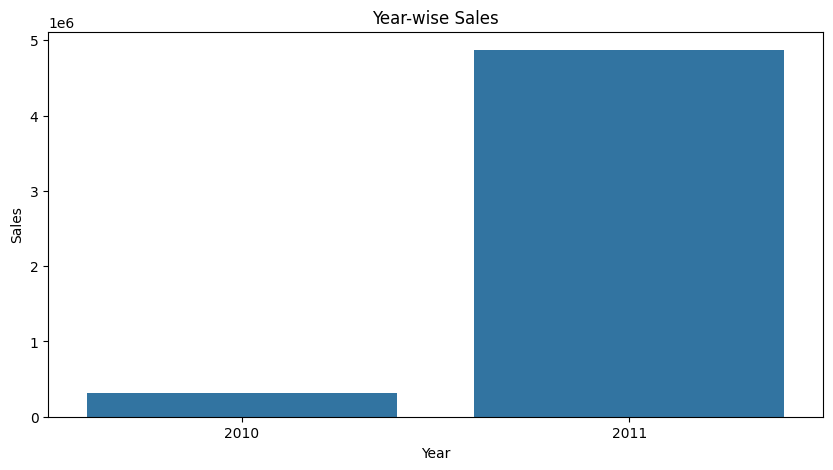

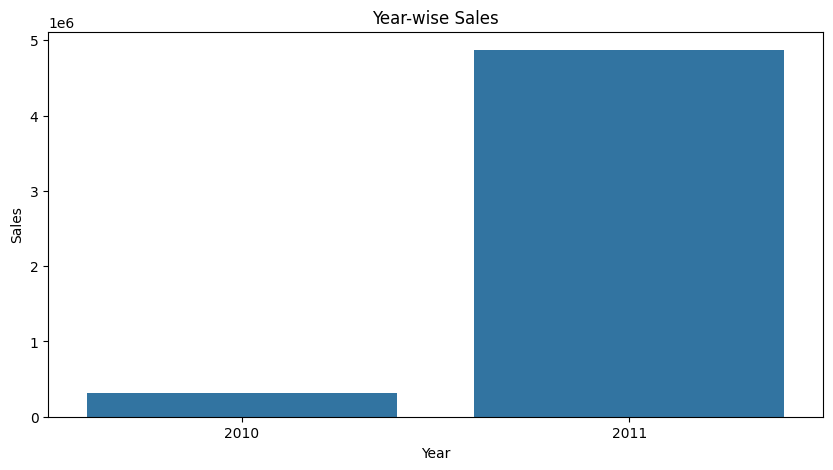

In [38]:

# Convert the 'InvoiceDate' column to datetime type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Group the data by year and calculate the total sales
sales_by_year = df.groupby(df['InvoiceDate'].dt.year)['Quantity'].sum()

# Create the bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_year.index, y=sales_by_year.values)
plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Sales")

# Show the plot
plt.show()



# no null customer
df_no_null_customer['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Group the data by year and calculate the total sales
sales_by_year = df_no_null_customer.groupby(df_no_null_customer['InvoiceDate'].dt.year)['Quantity'].sum()

# Create the bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_year.index, y=sales_by_year.values)
plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Sales")

# Show the plot
plt.show()

In [39]:
# installing apyori for Assciciation Discovery 
!pip install apyori

/Users/amani/miniconda3/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=77679) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5955 sha256=5c877ad5760f75ea063b19c71cfd0ab2b8edce45429106b0cf3dc85a2b4c4488
  Stored in directory: /Users/amani/Library/Caches/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [40]:
#Assciciation Discovery based on customerID

cust_level = df[["CustomerID", "Description"]].sort_values(by = "CustomerID", ascending = False) ## Selecting only required variables for modelling
cust_level['Description'] = cust_level['Description'].str.strip() # Removing white spaces if any
cust_level

,CustomerID,Description
198717,18287.0,SMALL RED BABUSHKA NOTEBOOK
392743,18287.0,SET/6 FROG PRINCE T-LIGHT CANDLES
392735,18287.0,PACK OF 12 50'S CHRISTMAS TISSUES
392736,18287.0,CHRISTMAS TREE HANGING SILVER
392737,18287.0,SET OF 2 CERAMIC CHRISTMAS TREES
...,...,...
72268,12347.0,BOX OF 6 ASSORTED COLOUR TEASPOONS
72269,12347.0,MINI LADLE LOVE HEART RED
72270,12347.0,CHOCOLATE CALCULATOR
72271,12347.0,TOOTHPASTE TUBE PEN


In [41]:
# create transaction list
transactions = [a[1]['Description'].tolist() for a in list(cust_level.groupby(['CustomerID']))] ## Combing all the items in list format for each cutomer

# train model
from apyori import apriori ## Importing apriori package
rules = apriori(transactions = transactions, min_support = 0.002, min_confidence = 0.05, min_lift = 3, min_length = 2, max_length = 2)
results = list(rules)

In [42]:
## Creating user-defined function for arranging the results obtained from model into readable format

def inspect(results):
    lhs         = [tuple(result[2][0][0])[0] for result in results]
    rhs         = [tuple(result[2][0][1])[0] for result in results]
    supports    = [result[1] for result in results]
    confidences = [result[2][0][2] for result in results]
    lifts       = [result[2][0][3] for result in results]
    return list(zip(lhs, rhs, supports, confidences, lifts))
resultsinDataFrame = pd.DataFrame(inspect(results), columns = ['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift'])

resultsinDataFrame.nlargest(n=50, columns="Lift") ## Showing best possible scenarios

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
218581,GREEN ENAMEL FLOWER RING,PURPLE ENAMEL FLOWER RING,0.002074,1.000000,394.454545
300362,NUMBER TILE COTTAGE GARDEN 0,NUMBER TILE COTTAGE GARDEN 8,0.002074,0.900000,355.009091
154155,DOLLY GIRL WALL ART,SPACEBOY WALL ART,0.002074,0.900000,325.425000
300378,NUMBER TILE COTTAGE GARDEN 3,NUMBER TILE COTTAGE GARDEN 9,0.002074,0.900000,325.425000
300383,NUMBER TILE COTTAGE GARDEN 6,NUMBER TILE COTTAGE GARDEN 9,0.002074,0.900000,325.425000
300360,NUMBER TILE COTTAGE GARDEN 0,NUMBER TILE COTTAGE GARDEN 4,0.002074,0.900000,300.392308
334801,PURPLE ENAMEL FLOWER RING,RED ENAMEL FLOWER RING,0.002074,0.818182,295.840909
73923,BLUE/YELLOW FLOWER DESIGN BIG MUG,YELLOW/PINK FLOWER DESIGN BIG MUG,0.002535,0.916667,284.101190
300359,NUMBER TILE COTTAGE GARDEN 0,NUMBER TILE COTTAGE GARDEN 2,0.002074,0.900000,278.935714
300361,NUMBER TILE COTTAGE GARDEN 0,NUMBER TILE COTTAGE GARDEN 7,0.002074,0.900000,278.935714


In [43]:
# Association discovery

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Load the data and sort by 'InvoiceDate'
df_no_null_customer['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df_no_null_customer = df_no_null_customer.sort_values(by='InvoiceDate')
df_no_null_customer = df_no_null_customer.set_index('InvoiceDate')

# Print dataset shape and information
#print('Dataset Shape:', df.shape)
#print(df.info())
#print(df.head())

# Add 'selled' column
df_no_null_customer['selled'] = 1

# Pivot the table
pivot = df_no_null_customer.pivot_table(values='selled', index='InvoiceNo', columns='Description').fillna(0)

# Print pivot table shape and information
#print('Pivot Table Shape:', pivot.shape)
#print(pivot.info())
#print(pivot.head())

# Keep the first 4104 columns
pivot = pivot.iloc[:, :4104]
#print(pivot.shape)

# Generate frequent items using Apriori algorithm
freq_items = apriori(pivot, min_support=0.02, use_colnames=True).sort_values(by='support', ascending=False)
#print(freq_items)

# Generate association rules
rules = association_rules(freq_items, metric='lift', min_threshold=1).sort_values(by='lift', ascending=False)


# Sort the rules based on the metric you are interested in (e.g., lift)
sorted_rules = rules.sort_values(by='confidence', ascending=False)

# Show the top 10 rules with the highest lift
top_rules = sorted_rules.head(10)

#top_rules.head()

/Users/amani/miniconda3/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [44]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules


# Convert the data into a transaction format
transactions = df.groupby('InvoiceNo')['Description'].apply(list).tolist()

# Apply one-hot encoding to the transaction data
te = TransactionEncoder()
encoded_data = te.fit_transform(transactions)
encoded_df = pd.DataFrame(encoded_data, columns=te.columns_)

# Generate frequent itemsets using Apriori
frequent_itemsets = apriori(encoded_df, min_support=0.01, use_colnames=True)

# Generate association rules with three products
association_rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
association_rules_three_products = association_rules[association_rules['antecedents'].apply(lambda x: len(x) == 2 and len(x.union({'Description'})) == 3)]

# Print the resulting association rules
print(association_rules_three_products)

sorted_rules = association_rules_three_products.sort_values(by='confidence', ascending=False)


                                           antecedents  \
600  (ALARM CLOCK BAKELIKE IVORY, ALARM CLOCK BAKEL...   
601  (ALARM CLOCK BAKELIKE IVORY, ALARM CLOCK BAKEL...   
602  (ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKEL...   
606  (ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...   
607  (ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...   
..                                                 ...   
925     (LUNCH BAG CARS BLUE, LUNCH BAG PINK POLKADOT)   
926     (LUNCH BAG CARS BLUE, LUNCH BAG RED RETROSPOT)   
927  (LUNCH BAG  BLACK SKULL., LUNCH BAG PINK POLKA...   
928  (LUNCH BAG  BLACK SKULL., LUNCH BAG RED RETROS...   
929  (LUNCH BAG PINK POLKADOT, LUNCH BAG RED RETROS...   

                                           consequents  antecedent support  \
600                        (ALARM CLOCK BAKELIKE RED )            0.014836   
601                       (ALARM CLOCK BAKELIKE GREEN)            0.016940   
602                       (ALARM CLOCK BAKELIKE IVORY)            0.0

In [45]:

association_rules_df = pd.DataFrame(sorted_rules)

association_rules_df.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
900,"(POPPY'S PLAYHOUSE BEDROOM , POPPY'S PLAYHOUSE...",(POPPY'S PLAYHOUSE KITCHEN),0.011060,0.018666,0.010035,0.907317,48.607021,1.0,0.009828,10.588073,0.990380,0.509589,0.905554,0.722445
619,"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",(GREEN REGENCY TEACUP AND SAUCER),0.023522,0.037279,0.021040,0.894495,23.994742,1.0,0.020163,9.124923,0.981409,0.529172,0.890410,0.729447
613,"(REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP...",(GREEN REGENCY TEACUP AND SAUCER),0.016670,0.037279,0.014620,0.877023,23.526037,1.0,0.013999,7.828443,0.973726,0.371742,0.872261,0.634604
902,"(POPPY'S PLAYHOUSE LIVINGROOM , POPPY'S PLAYHO...",(POPPY'S PLAYHOUSE BEDROOM ),0.011599,0.017048,0.010035,0.865116,50.746188,1.0,0.009837,7.287403,0.991798,0.539130,0.862777,0.726862
895,"(REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP...",(ROSES REGENCY TEACUP AND SAUCER ),0.016670,0.042242,0.014297,0.857605,20.302132,1.0,0.013592,6.726072,0.966862,0.320435,0.851325,0.598024
620,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.024817,0.042242,0.021040,0.847826,20.070631,1.0,0.019992,6.293837,0.974356,0.457210,0.841114,0.672955
625,"(REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACU...",(ROSES REGENCY TEACUP AND SAUCER ),0.020177,0.042242,0.016832,0.834225,19.748643,1.0,0.015980,5.777443,0.968913,0.369231,0.826913,0.616346
632,"(JUMBO BAG PINK POLKADOT, JUMBO BAG STRAWBERRY)",(JUMBO BAG RED RETROSPOT),0.015807,0.086319,0.012516,0.791809,9.173106,1.0,0.011152,4.388667,0.905296,0.139675,0.772140,0.468404
643,"(JUMBO STORAGE BAG SUKI, JUMBO BAG PINK POLKADOT)",(JUMBO BAG RED RETROSPOT),0.015160,0.086319,0.011869,0.782918,9.070107,1.0,0.010560,4.208926,0.903444,0.132450,0.762410,0.460209
600,"(ALARM CLOCK BAKELIKE IVORY, ALARM CLOCK BAKEL...",(ALARM CLOCK BAKELIKE RED ),0.014836,0.047313,0.011599,0.781818,16.524267,1.0,0.010897,4.366481,0.953631,0.229456,0.770983,0.513486
